# Breast Cancer Detection
#### Support Vector Machines for Medical Classification

#### Project Overview

Breast cancer is one of the most common cancers worldwide. Early and accurate classification of tumors as **benign** or **malignant** is critical - a false negative (failing to detect a malignant tumor) can have severe consequences for a patient's prognosis

This project built a binary classification model using **Support Vector Machines (SVM)**, a distance-based algorithm particularly well suited for high dimensional medical data. Beyond achieving good predictive performance, the project is designed as a n in depth exploration of how SVMs behave under different configurations, providing intuition about the geometry behind the algorithm.

- **Feature selection:** 
- **Feature scaling:** How does standardization affect a distance-based model?
- **Decision boundaries:**  What does the separation between classes look like geometrically?
- **Kernel functions:** Linear, Polynomial, and Gaussian (RBF) Kernels are compared.
- **Hyper parameter sensitivity:** How do C and Gamma control the bias-variance tradeoff?

---

#### Dataset

The dataset contains **569 observations** and **30 numerical features** describing geometric characteristics of cell nuclei extracted from breast mass images (radius, texture, perimeter, area, concavity, symmetry, among others).

| Class | Label | Count | Proportion |
|-------|-------|-------|------------|
| Benign | B | 357 | 62.7% |
| Malignant | M | 212 | 37.3% |

The dataset presents a moderate class imbalance, which is accounted for in the evaluation strategy.

---

#### Evaluation Metric

**F1 Score** is used as the primary metric. in a medical context, both false positive and false negative carry real costs:

- A **false negative** (malignant classified as benign) delays treatment - potentially life-threatening.
- A **false positive** (benign classified as malignant) causes unnecessary procedures and patient anxiety.

F1 score Balances Precision and Recall, making it more appropriate than raw Accuracy for this imbalanced, high-stakes classification task.

---

#### Project Workflow

1. Exploratory Data Analysis (EDA)
2. Train/Test split with stratification
3. Linear SVM — 2 features, no scaling
4. Linear SVM — 2 features, with scaling
5. Linear SVM — all 29 features, with scaling
6. Polynomial SVM (LinearSVC + PolynomialFeatures)
7. Polynomial kernel SVM (kernel trick)
8. Gaussian (RBF) SVM — gamma sensitivity analysis
9. Final model comparison

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

### 1. Dataset Loading

The dataset is loaded and its structure inspected. Each row represents a patient, each column a geometric mesurement of the cell nucleus extracted from a digitized image of a fine needle aspirate (FNA) of a breast mass.

In [2]:
df = pd.read_csv("breast-cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### 2. EDA
Before Building any model, it is important to understand the structure of the data: the distribution of classes, potential separability between them, and relationships among features.

In [3]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

<Axes: xlabel='diagnosis', ylabel='count'>

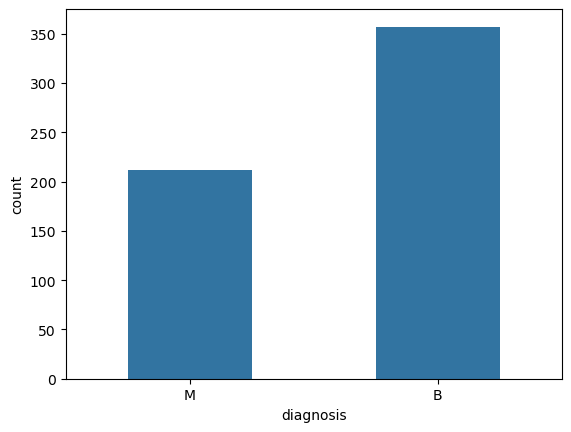

In [5]:
import seaborn as sns
sns.countplot(data=df, x="diagnosis", width=0.5)

The class distribution shows a moderate imbalance: **~63% benign** and **~37% malignant**. While the imbalance is real, it is not severe enough to require resampling techniques such as SMOTE for this analysis. The F1 Score metric is sufficient to account for it during evaluation.

In [6]:
corr = df.corr(numeric_only=True)

<Axes: >

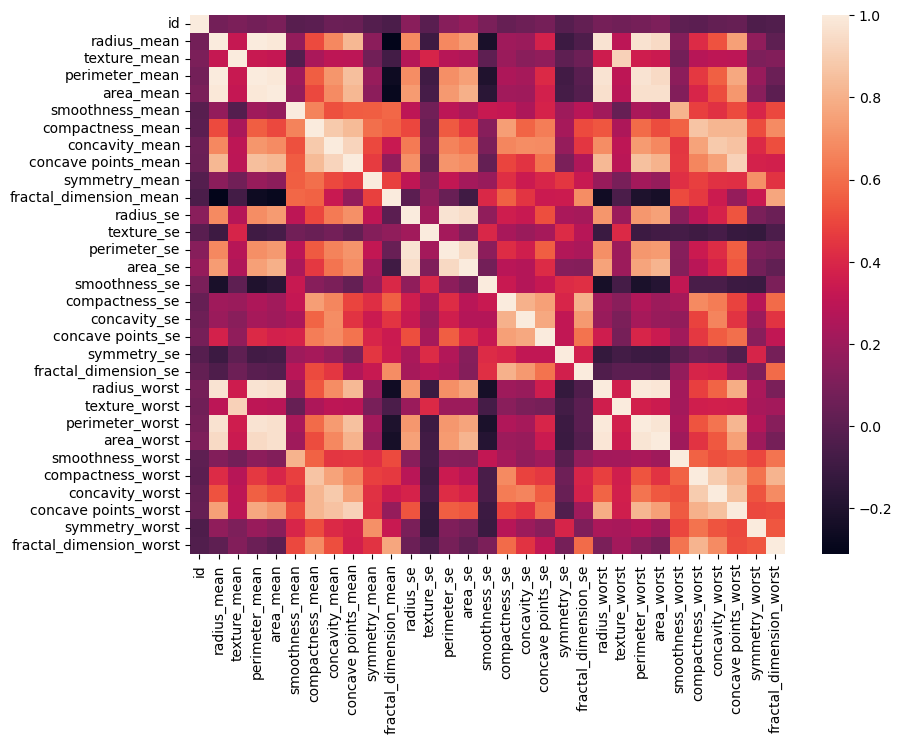

In [7]:
plt.figure(figsize =(9.6,7))
sns.heatmap(corr)

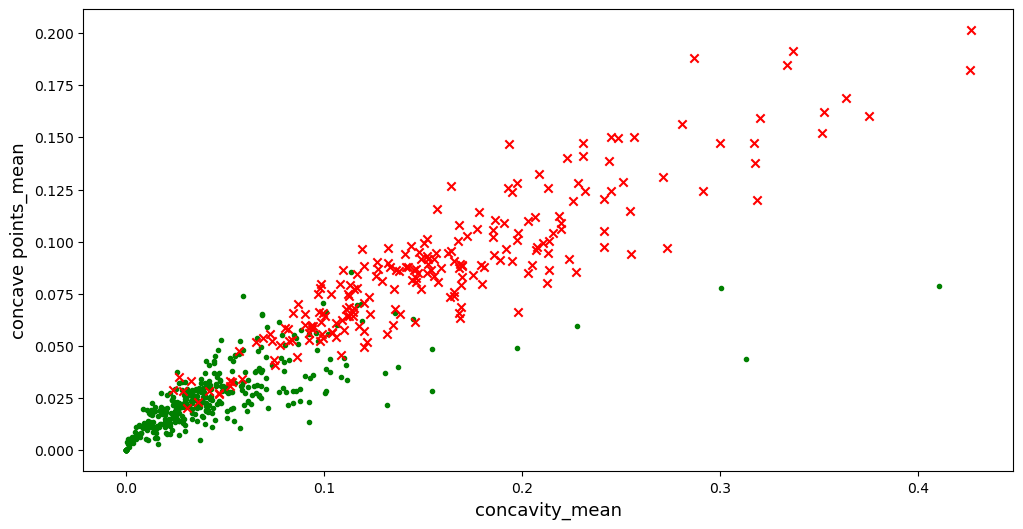

In [8]:
plt.figure(figsize=(12, 6))
plt.scatter(df["concavity_mean"][df['diagnosis'] == "B"], df["concave points_mean"][df["diagnosis"]=="B"], c='g', marker=".")
plt.scatter(df["concavity_mean"][df['diagnosis'] == "M"], df["concave points_mean"][df["diagnosis"]=="M"], c='r', marker="x")
plt.xlabel("concavity_mean", fontsize=13)
plt.ylabel("concave points_mean", fontsize=13)
plt.show()

The correlation heatmap confirms that many features are highly correlated with each other (especially among the `_mean`, `_se`, and `_worst` groups), which is expected since they describe the same geometric properties at different statistical levels.

The scatter plot reveals a clear separation tendency between benign (green) and malignant (red) tumors along both concavity dimensions - particularly for high values of `concavity_ mean`. This suggest these features carry strong discriminative power and are good candidates for a simplified model.

### 3. Dataset Split

The dataset is split into **80% training** and **20% test** sets. Stratified is used to preserve the original class proportion in both sets, which is especially important given the class imbalance.
>The test set is held out entirely and only used for final evaluation, and never for model selection or hyperparameter decisions.

In [9]:
df = df.drop("id", axis=1)
train_set, test_set = train_test_split(df, test_size= 0.2, stratify=df["diagnosis"], random_state=137)

In [10]:
X_train = train_set.drop("diagnosis", axis=1)
y_train = train_set["diagnosis"].copy()

X_test = test_set.drop("diagnosis", axis=1)
y_test = test_set["diagnosis"].copy()

### 4. SVM (Linear Kernel)

A linear SVM seeks hyperplane that separates the two classes with the **maximum margin**. The paraeter **C** controls the regularization: a high C penalizes misclassifications heavily (thighter fit), while a low **C** allows more violations in exchange for wider margin.

#### 4.1 Simplified dataset - 2 Features, no scaling

To build geometric intuition, the model is first trained using only `concavity_mean` and `concave points_mean`, the two features that showed a clear visual separation in the EDA. This allows the decision boundary to be visualized in 2D space.

In [11]:
X_train_simple = X_train[["concavity_mean", "concave points_mean"]].copy()
X_test_simple = X_test[["concavity_mean", "concave points_mean"]].copy()

In [12]:
X_train_simple

,concavity_mean,concave points_mean
277,0.08020,0.05843
3,0.24140,0.10520
152,0.41080,0.07857
186,0.08169,0.05814
311,0.01447,0.01877
...,...,...
75,0.09769,0.06638
506,0.08175,0.02166
482,0.05786,0.05266
490,0.01714,0.01261


In [13]:
from sklearn.svm import SVC

#SVM Large Margin Classification.
svm_clf = SVC(kernel="linear", C=1000)
svm_clf.fit(X_train_simple, y_train)

,C,1000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


**Decision boundary representation**

The plot shows the learned decision boundary (solid line) and the margin gutters (dashed lines). Points highlighted in pink are the **support vectors**, the training examples closest to the boundary that define the margin. Notice that the boundary struggles in the overlap region, which is reflected in the F1 Score below.

In [14]:
def plot_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    x0 = np.linspace(xmin, xmax, 200) # REVISAR
    decision_boundary = -w[0]/w[1] * x0 -b/w[1] # REVISAR

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors="#FFAAAA")
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

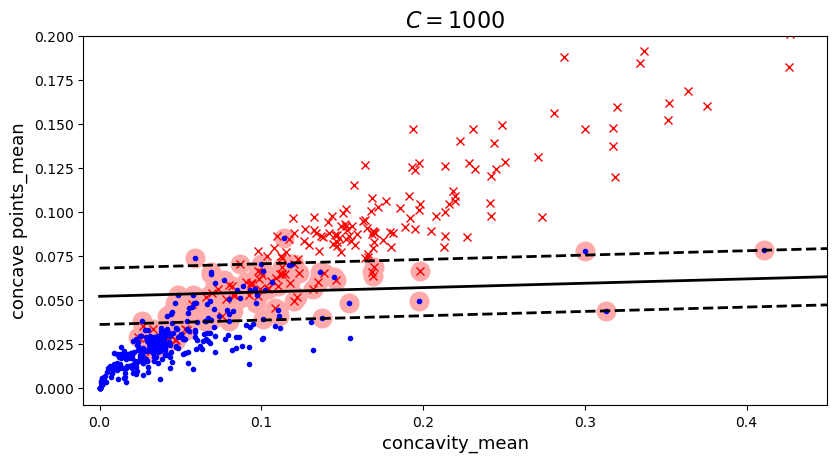

In [15]:
plt.figure(figsize=(9.6, 4.8))
plt.plot(X_train_simple.values[:, 0][y_train=="M"], X_train_simple.values[:, 1][y_train=="M"], "rx")
plt.plot(X_train_simple.values[:, 0][y_train=="B"], X_train_simple.values[:, 1][y_train=="B"], "b.")
plot_decision_boundary(svm_clf, 0, 1)
plt.title("$C = {}$".format(svm_clf.C), fontsize=16)
plt.axis([-0.010, 0.45, -0.010, 0.200])
plt.xlabel("concavity_mean", fontsize=13)
plt.ylabel("concave points_mean", fontsize=13)
plt.show()

**Model Evaluation - 2 features no scaling**

In [16]:
y_pred = svm_clf.predict(X_test_simple)

In [17]:
print("F1 Score:", f1_score(y_test, y_pred, pos_label='M'))

F1 Score: 0.8641975308641975


> **Key insight:** SVMs are fundamentally distance-based algorithms. When features have very different scales, the model implicitly assigns more weight to features with larger numerical ranges, not because they are more informative, but simply because they dominate the distance calculation. **Standardizing features is not optional for SVMs, it is a prerequisite.**

The next step applies `StandardScaler` to bring all features to the same scale before fitting.

In [18]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

svm_clf_std = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

svm_clf_std.fit(X_train_simple, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [19]:
y_pred_std = svm_clf_std.predict(X_test_simple)

In [20]:
print("F1 score:", f1_score(y_test,y_pred_std, pos_label='M'))

F1 score: 0.8860759493670886


An F1 Score of **0.886** with only 2 scaled features is already strong. However, we are using just 2 of the 29 available features. Training on the full feature set should capture considerably more information about the tumor geometry.

#### 4.2 Real Dataset - All 29 features

Using the raw (unscaled) dataset in 29 dimensions creates two compounding problems:

1. **Computational cost:** optimizing the SVM in high-dimensional space is already expensive.
2. **Scale imbalance:** features like `area_mean` (values ~100–2500) completely overshadow features like `fractal_dimension_mean` (values ~0.05–0.20). The model tries to minimize distances across a geometrically distorted space.

Applying `StandardScaler` resolves both issues by normalizing every feature to zero mean and unit variance.

In [21]:
#SVM Large Margin Classification.
#svm_clf = SVC(kernel="linear", C=1)
#svm_clf.fit(X_train, y_train)

In [22]:
#y_pred = svm_clf.predict(X_test)

In [23]:
#print("F1 Score:", f1_score(y_test, y_pred, pos_label='M  '))

The scaled full-feature model reaches an **F1 Score of 0.988**, a substantial improvement over the 2-feature version. This confirms that the remaining 27 features, while individually weaker, collectively add significant discriminative power.

At this point, the linear kernel is performing exceptionally well. The next question is: can a non-linear kernel do better, or at least provide richer geometric insight?

In [24]:
svm_clf_std.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [25]:
y_pred = svm_clf_std.predict(X_test)

In [26]:
print("F1 Score:", f1_score(y_test, y_pred, pos_label='M'))

F1 Score: 0.9879518072289156


**Now we can compare the F1 score between the model trained with only two features and the one trained with all the available features, additionally applying feature scaling to optimize the geometrical space (0.886 vs 0.987). This level of performance is remarkable, but it is now worth exploring a different kernel for the SVM model.**

### 5. Non-Linear SVM Kernels

A linear boundary may not be sufficient if the classes are not linearly separable in the original feature space. **Kernel functions** implicitly map the data into a higher-dimensional space where a linear boundary corresponds to a non-linear boundary in the original space — this is the **kernel trick**.

Two non-linear kernels are explored: Polynomial and Gaussian (RBF).

#### 5.1 Polynomial Kernel I (Explicit Feature Expansion)

The first approach uses `PolynomialFeatures` to explicitly expand the 2-feature space into all polynomial combinations up to degree 3, then fits a `LinearSVC` on the expanded space. This is mathematically equivalent to a polynomial kernel but makes the transformation explicit and interpretable.

In [27]:
# In order to represent the decision threshold it's requiered to convert the dependent variable to numerical.
y_train_num = y_train.map({"B": 0, "M": 1})
y_test_num = y_test.map({"B": 0, "M": 1})

In [28]:
from sklearn.datasets import make_moons
from sklearn.svm import LinearSVC
from sklearn.preprocessing import PolynomialFeatures

poly_svm_clf = Pipeline([
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=30, loss="hinge", random_state=42, max_iter=100000, dual=True))
    ])

poly_svm_clf.fit(X_train_simple, y_train_num)

,steps,"[('poly_features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [29]:
def plot_dataset(X, Y):
    plt.plot(X[:, 0][Y==0], X[:,1][Y==0], "b.")
    plt.plot(X[:, 0][Y==1], X[:,1][Y==1], "r.")

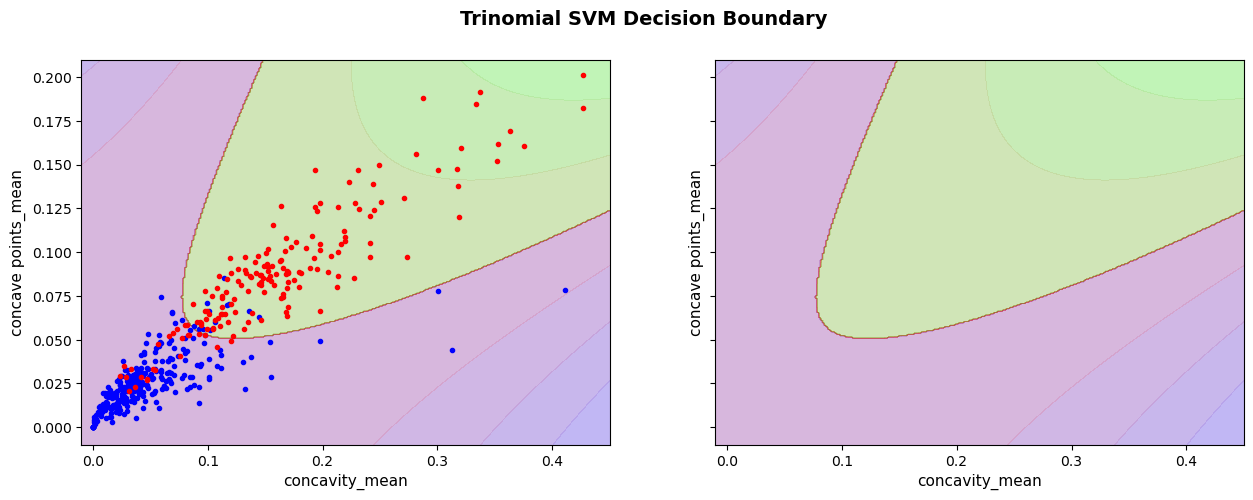

In [30]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 300)
    x1s = np.linspace(axes[2], axes[3], 300)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = pd.DataFrame(
    np.c_[x0.ravel(), x1.ravel()],
    columns=X_train_simple.columns)
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha = 0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha = 0.1)

fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
fig.suptitle("Trinomial SVM Decision Boundary", fontsize=14, fontweight="bold")
plt.sca(axes[0])
plot_dataset(X_train_simple.values, y_train_num)
plot_predictions(poly_svm_clf, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.sca(axes[1])
plot_predictions(poly_svm_clf, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.show()

In [31]:
y_pred = poly_svm_clf.predict(X_test_simple)

In [32]:
print("F1 Score:", f1_score(y_test_num, y_pred))

F1 Score: 0.925


#### 5.2 Polynomial Kernel II (Kernel Trick)

The second approach uses the `kernel='poly'` option in `SVC`, which applies the polynomial kernel implicitly via the kernel trick — no explicit feature expansion is needed. This is computationally more efficient, especially in higher dimensions.

The parameter `coef0` controls the influence of lower-degree terms in the polynomial.

The model is first evaluated on the 2-feature simplified dataset to allow visualization of the non-linear decision boundary, then retrained on the full 29-feature dataset for performance comparison.

In [33]:
svm_clf_poly  = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(C=20, kernel='poly', degree=3, coef0=10))
])

svm_clf_poly.fit(X_train_simple, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,20
,kernel,'poly'
,degree,3
,gamma,'scale'


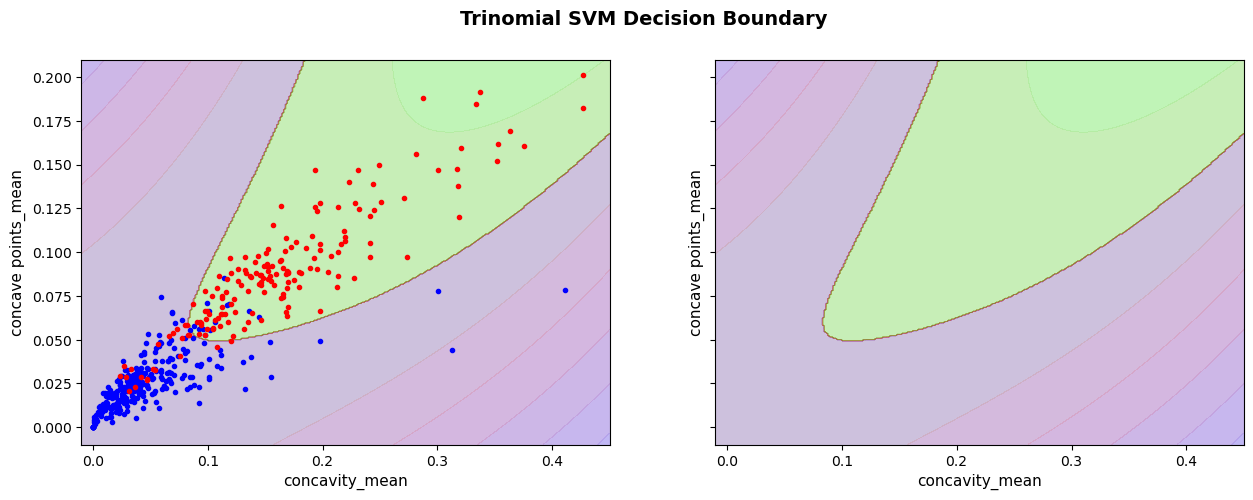

In [34]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
fig.suptitle("Trinomial SVM Decision Boundary", fontsize=14, fontweight="bold")
plt.sca(axes[0])
plot_dataset(X_train_simple.values, y_train_num)
plot_predictions(svm_clf_poly, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.sca(axes[1])
plot_predictions(svm_clf_poly, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.show()

In [35]:
y_pred = svm_clf_poly.predict(X_test_simple)

In [36]:
print("F1 score:", f1_score(y_test_num, y_pred))

F1 score: 0.9113924050632911


**Full Dataset Evaluation**

In [37]:
svm_clf_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(C=40, kernel='poly', degree=3, coef0=10))
])

svm_clf_poly.fit(X_train, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,40
,kernel,'poly'
,degree,3
,gamma,'scale'


In [38]:
y_pred = svm_clf_poly.predict(X_test)

In [39]:
print("F1 Score:", f1_score(y_test_num, y_pred))

F1 Score: 0.9761904761904762


### 6. Gaussian Kernel

The **Radial Basis Function (RBF)** kernel is the most flexible of the three. It can model arbitrarily complex decision boundaries by measuring similarity as a function of distance between data points.

The **gamma** parameter controls how far the influence of each training point reaches:
- **Low gamma:** each point has a wide influence → smoother, more general boundary → risk of underfitting.
- **High gamma:** each point has a narrow influence → the boundary wraps tightly around each training point → risk of overfitting.

Four gamma values are tested (0.01, 0.1, 1, 10) to observe this bias-variance tradeoff in action.

**Training on 2 features - gamma analysis**

The decision boundaries are first visualized in 2D to build intuition about how gamma shapes the boundary before applying the model to the full dataset.

In [40]:
rbf_svm_clf_min = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='rbf', gamma=0.01, C=1000))
])

rbf_svm_clf_min.fit(X_train_simple, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,0.01


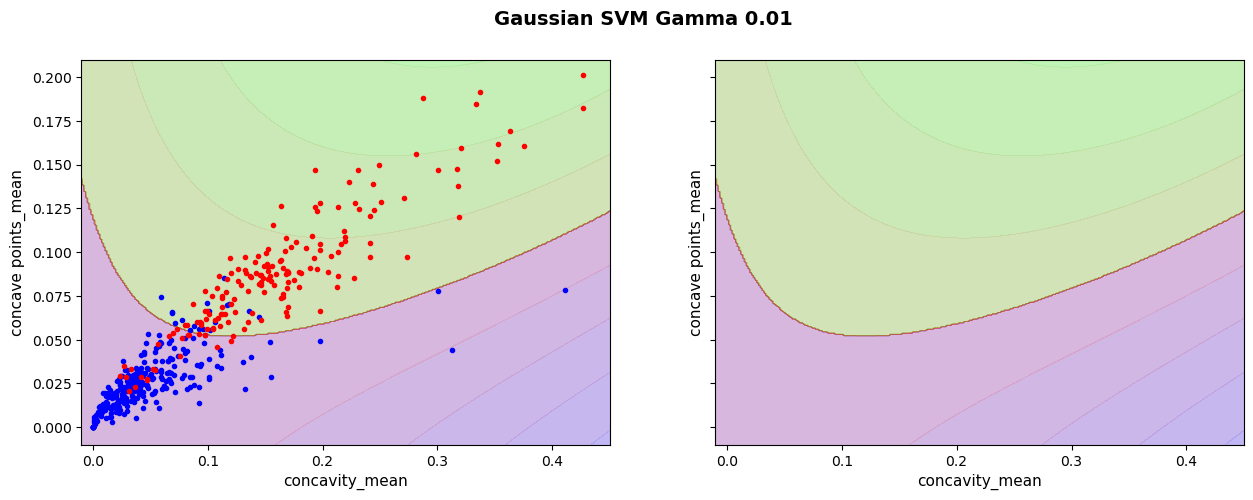

In [41]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
fig.suptitle("Gaussian SVM Gamma 0.01", fontsize=14, fontweight="bold")
plot_dataset(X_train_simple.values, y_train_num)
plot_predictions(rbf_svm_clf_min, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.sca(axes[1])
plot_predictions(rbf_svm_clf_min, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.show()

In [42]:
rbf_svm_clf_min.fit(X_train, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,0.01


In [43]:
y_pred = rbf_svm_clf_min.predict(X_test)

In [44]:
print("F1 Score w/ gamma 0.01:", f1_score(y_test_num, y_pred))

F1 Score w/ gamma 0.01: 0.9761904761904762


In [45]:
rbf_svm_clf_01 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='rbf', gamma=0.1, C=1000))
])

rbf_svm_clf_01.fit(X_train_simple, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,0.1


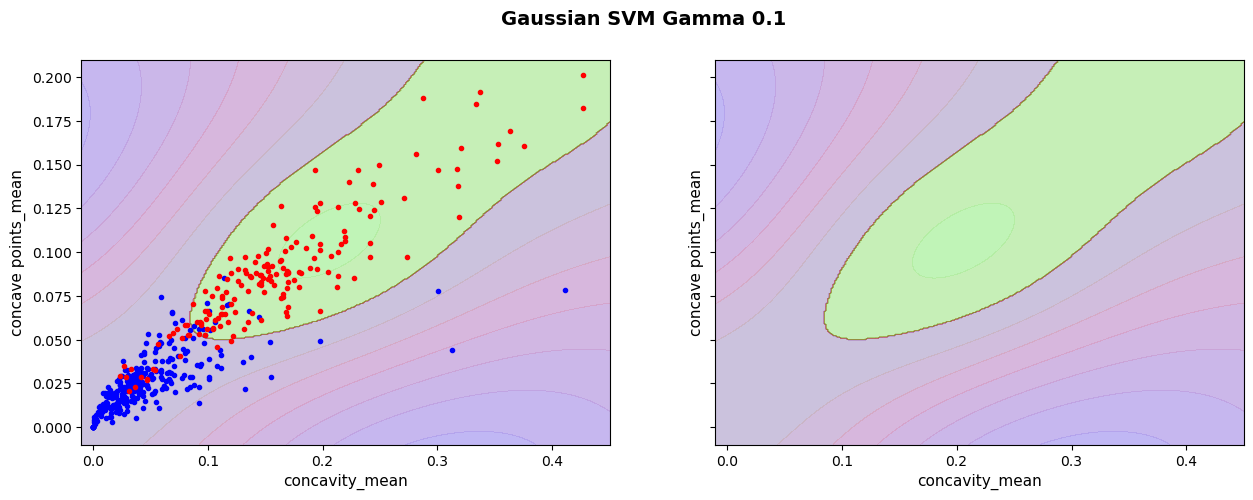

In [46]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
fig.suptitle("Gaussian SVM Gamma 0.1", fontsize=14, fontweight="bold")
plot_dataset(X_train_simple.values, y_train_num)
plot_predictions(rbf_svm_clf_01, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.sca(axes[1])
plot_predictions(rbf_svm_clf_01, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.show()

In [47]:
rbf_svm_clf_01.fit(X_train, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,0.1


In [48]:
y_pred = rbf_svm_clf_01.predict(X_test)

In [49]:
print("F1 Score w/ gamma 0.1:", f1_score(y_test_num, y_pred))

F1 Score w/ gamma 0.1: 0.9647058823529412


In [50]:
rbf_svm_clf_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='rbf', gamma=1, C=1000))
])

rbf_svm_clf_1.fit(X_train_simple, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,1


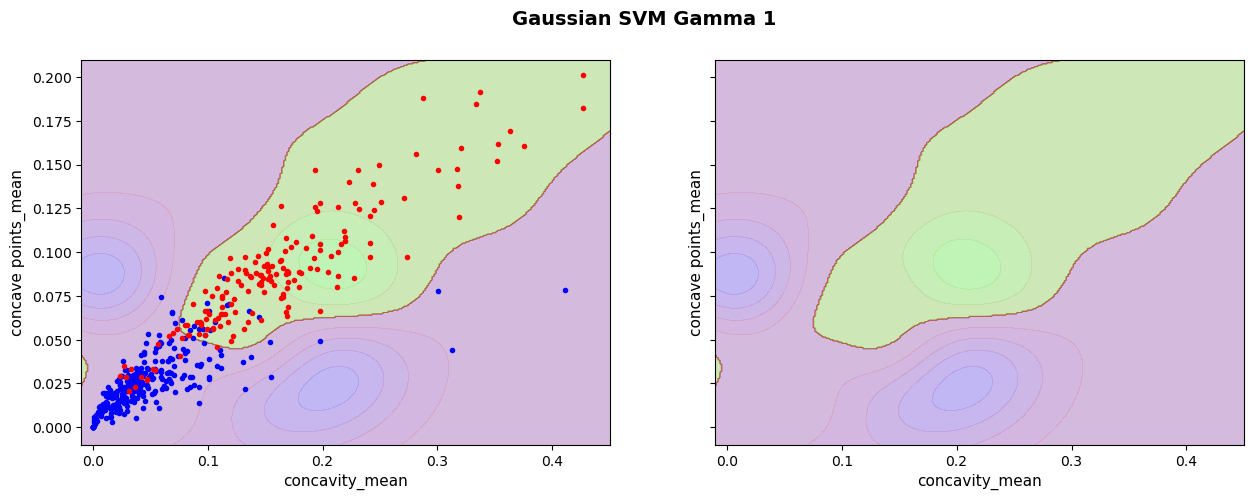

In [51]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
fig.suptitle("Gaussian SVM Gamma 1", fontsize=14, fontweight="bold")
plot_dataset(X_train_simple.values, y_train_num)
plot_predictions(rbf_svm_clf_1, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.sca(axes[1])
plot_predictions(rbf_svm_clf_1, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.show()

In [52]:
rbf_svm_clf_1.fit(X_train, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,1


In [53]:
y_pred = rbf_svm_clf_1.predict(X_test)

In [54]:
print("F1 Score w/ gamma 1:", f1_score(y_test_num, y_pred))

F1 Score w/ gamma 1: 0.09090909090909091


In [55]:
rbf_svm_clf_10 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel='rbf', gamma=10, C=1000))
])

rbf_svm_clf_10.fit(X_train_simple, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,10


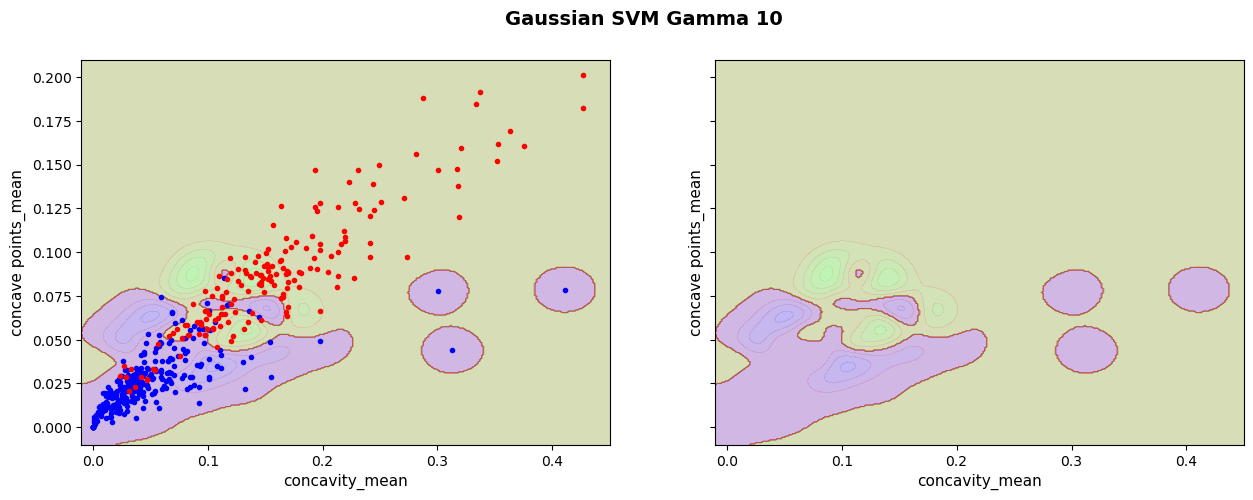

In [56]:
fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
fig.suptitle("Gaussian SVM Gamma 10", fontsize=14, fontweight="bold")
plot_dataset(X_train_simple.values, y_train_num)
plot_predictions(rbf_svm_clf_10, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.sca(axes[1])
plot_predictions(rbf_svm_clf_10, [-0.010, 0.45, -0.010, 0.210])
plt.xlabel("concavity_mean", fontsize=11)
plt.ylabel("concave points_mean", fontsize=11)
plt.show()

#### Full Dataset Evaluation — RBF Kernel

The best-performing gamma value from the visual analysis is applied to the full 29-feature dataset for final F1 Score comparison.

In [57]:
rbf_svm_clf_10.fit(X_train, y_train_num)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1000
,kernel,'rbf'
,degree,3
,gamma,10


In [58]:
y_pred = rbf_svm_clf_10.predict(X_test)

In [59]:
print("F1 Score w/ gamma 10:", f1_score(y_test_num, y_pred))

F1 Score w/ gamma 10: 0.0


#### Conclusions

This project explored how **Support Vector Machines** behave under different configurations for a medical classification task. Several important lessons emerge from the experiments.

**Feature selection matters, but is not a substitute for completeness.** A linear SVM trained on just two concavity-related features achieved an F1 Score of ~0.87 without scaling and ~0.886 with scaling. These results are respectable for a 2-variable model and confirm that `concavity_mean` and `concave points_mean` are among the most discriminative features in the dataset. However, incorporating all 29 features pushed the **F1 Score to 0.988**, demonstrating that the remaining features capture complementary information that a simplified model cannot recover.

**Feature scaling is non-negotiable for SVMs.** Because the algorithm optimizes margins in terms of Euclidean distance, features with large numerical ranges dominate the geometry regardless of their actual predictive value. Standardizing all features to zero mean and unit variance is not a minor preprocessing step — it is a structural requirement for the algorithm to function correctly.

**Non-linear kernels add flexibility, but introduce new risks.** The polynomial and RBF kernels both produced competitive results with moderate hyperparameter values. However, the RBF kernel experiments revealed a critical pattern: as gamma increases from 0.01 to 0.1, performance remains strong; but at gamma = 1, the F1 Score collapses to ~0.09, and at gamma = 10 it reaches 0.0. This dramatic degradation is a textbook example of **severe overfitting** — the model memorizes the training data to the point where it loses all generalization ability.

**The linear kernel was the strongest overall performer on this dataset.** An F1 Score of 0.988 with a linear boundary suggests that the 29-dimensional feature space is nearly linearly separable after standardization. Adding kernel complexity does not improve and, when poorly tuned, substantially degrades performance.

---

*From a clinical perspective, an F1 Score of 0.988 means the model would incorrectly classify approximately 1 in 85 tumors. While this is a strong result for a baseline model, real medical deployment would require additional validation (cross-validation, external test sets, calibration) and close collaboration with clinical experts before any diagnostic use.*